# Notebook 6 — **3D crosswind** (deterministic forward PINN)
### Wind-relative drag · elevation *and* azimuth · an *inferred* impact time

**Where I am in the project.** Notebooks 1–5 lived in a flat, deterministic world: a 2-D
plane, a single launch angle, and — at worst — a steady drag coefficient. This notebook steps
up into three dimensions with a crosswind. Two things change, and each is a genuine physics /
maths step up, not just more code:

1. **3-D crosswind.** Drag no longer opposes my ground velocity — it opposes my velocity
   *relative to the moving air*. A sideways wind therefore bleeds sideways momentum in and
   pushes the projectile off-line. I need a third spatial axis and two launch angles
   (**elevation** *and* **azimuth**).
2. **An *inferred* impact time.** In Notebook 3 I looked flight time up from a precomputed
   RK4 table. In 3-D-with-wind that table would need 5 axes — hopeless. So I make the impact
   time a *learned output* of a small second network, trained by the landing condition itself.

**My roadmap for this notebook.** 3-D wind-relative physics → RK4 ground truth → a forward
PINN that generalises over $(\theta,\phi,k,\mathbf w)$ **and infers its own impact time** →
validate against RK4 → a small sensitivity map over azimuth and crosswind. Everything here is
**deterministic**: one set of inputs gives exactly one trajectory.

## Setup
Same tools as before: PyTorch for the network + autograd, NumPy for the numerical ground
truth (RK4), and Matplotlib for plots. Seeds fixed so every number here is reproducible.


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
# torch      : neural network + automatic differentiation (our physics residuals)
# torch.nn   : ready-made layers (Linear, Tanh) and the Module base class
# numpy      : the CPU "ground truth" integrator (RK4)
# matplotlib : all plots, including the 3-D trajectory view
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: enables 3-D plotting

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Reproducibility: same seed -> same random collocation points every run.
torch.manual_seed(0)
np.random.seed(0)

Device: cpu


## The physics, written out carefully
**My coordinates.** I keep $y$ pointing **up** (so gravity is $-g\,\hat{\mathbf y}$, exactly as
in every earlier notebook) and add a third horizontal axis:
- $x$ = **downrange** (the direction I am nominally aiming),
- $y$ = **vertical** (up),
- $z$ = **crossrange** (horizontal, at right angles to $x$ — the way a crosswind blows).

**Two launch angles now.** In 2-D one angle (elevation $\theta$) was enough. In 3-D I also
need an **azimuth** $\phi$ — the compass heading in the horizontal plane. With launch speed
$u$:
$$ v_x(0)=u\cos\theta\cos\phi,\qquad v_y(0)=u\sin\theta,\qquad v_z(0)=u\cos\theta\sin\phi. $$
Sanity: the horizontal speed is $u\cos\theta$, split between downrange and crossrange by the
azimuth; $\phi=0$ recovers my old 2-D launch exactly.

**The one idea that changes everything: wind-relative drag.** A projectile does not "feel" the
ground — it feels the *air rushing past it*. If the air itself moves with wind velocity
$\mathbf w=(w_x,w_y,w_z)$, then what drives drag is the **air-relative velocity**
$$ \mathbf v_{\text{rel}}=\mathbf v-\mathbf w. $$
Quadratic drag opposes *that* vector with magnitude $\propto|\mathbf v_{\text{rel}}|^2$, so
Newton's second law (per unit mass, with $k=b/m$) becomes
$$ \dot{\mathbf v}= -g\,\hat{\mathbf y}\;-\;k\,\lvert\mathbf v-\mathbf w\rvert\,(\mathbf v-\mathbf w). $$
Writing it out per component with a **horizontal** wind $\mathbf w=(w_x,0,w_z)$ and
$v_{\text{rel}}=\sqrt{(v_x-w_x)^2+v_y^2+(v_z-w_z)^2}$:
$$ \dot v_x=-k\,v_{\text{rel}}\,(v_x-w_x),\quad
   \dot v_y=-g-k\,v_{\text{rel}}\,v_y,\quad
   \dot v_z=-k\,v_{\text{rel}}\,(v_z-w_z). $$

**Why this is the physically correct move (and a common trap).** It is tempting to just add a
sideways force, but that is wrong: drag is *nonlinear* in the air-relative speed, so a
crosswind does not only push sideways — by changing $v_{\text{rel}}$ it also subtly changes the
downrange and vertical drag. Using $\mathbf v-\mathbf w$ inside the *magnitude* is what captures
that coupling. Set $\mathbf w=\mathbf 0$ and $\phi=0$ and every equation collapses back to
Notebook 3 — so this notebook strictly *contains* the old one.

In [2]:
# ── Physical constants and the ranges we will generalise over ──────────────────
g = 9.81                       # gravity (m/s^2), acts along -y

u_fixed = 30.0                 # launch SPEED fixed at 30 m/s (as in Notebook 3);
                               # we generalise over the two ANGLES, drag, and WIND.

# The PINN will learn EVERY combination inside these boxes:
theta_min, theta_max = 30.0, 60.0     # elevation (deg above horizontal)
phi_min,   phi_max   = -15.0, 15.0    # azimuth   (deg left/right of downrange); 0 = straight
k_min,     k_max     = 0.0,  0.02     # drag-per-unit-mass (1/m); 0 = vacuum
w_min,     w_max     = -8.0, 8.0      # horizontal wind component (m/s) on each of x,z

print(f"Launch speed (fixed) : {u_fixed} m/s")
print(f"Elevation theta      : {theta_min}-{theta_max} deg")
print(f"Azimuth   phi        : {phi_min}-{phi_max} deg")
print(f"Drag      k          : {k_min}-{k_max} 1/m")
print(f"Wind (wx, wz) each   : {w_min}-{w_max} m/s")

Launch speed (fixed) : 30.0 m/s
Elevation theta      : 30.0-60.0 deg
Azimuth   phi        : -15.0-15.0 deg
Drag      k          : 0.0-0.02 1/m
Wind (wx, wz) each   : -8.0-8.0 m/s


## All the physics in one function
As in Notebook 3 I pack the whole state into a vector and write a single `deriv3d(s)` that
returns $\dot s$. This one function *is* the physics; the RK4 integrator below just calls it
repeatedly. The state is now 6-dimensional, $s=[x,y,z,v_x,v_y,v_z]$, and the wind enters only
through the air-relative velocity.

In [3]:
# ── Right-hand side of the 3-D ODE system: ds/dt = deriv3d(s) ─────────────────
# State s = [x, y, z, vx, vy, vz]. Wind is a 3-vector (we use horizontal winds).
# The ONLY new idea vs Notebook 3 is (vx-wx, vy-wy, vz-wz): the AIR-relative velocity.
def deriv3d(s, k, wind):
    x, y, z, vx, vy, vz = s
    wx, wy, wz = wind
    vrx, vry, vrz = vx - wx, vy - wy, vz - wz          # air-relative velocity components
    vrel = np.sqrt(vrx*vrx + vry*vry + vrz*vrz)         # air-relative SPEED (drives drag)
    ax = -k * vrel * vrx                                 # drag only (no gravity sideways)
    ay = -g - k * vrel * vry                             # gravity + drag
    az = -k * vrel * vrz                                 # drag only
    return np.array([vx, vy, vz, ax, ay, az])           # = ds/dt

## RK4 in 3-D, and detecting the landing
Nothing about Runge–Kutta 4 changes when the state grows from 4 to 6 numbers — RK4 samples the
slope four times per step and takes a weighted average, and it does that componentwise. I march
until $y$ crosses zero (the projectile lands) and linearly interpolate the exact landing state,
which gives me a clean impact point $(x,z)$ and impact time. This RK4 solution is my **trusted
ground truth** for the whole deterministic part.

In [4]:
# ── One RK4 step (identical structure to Notebook 3, just a 6-vector state) ────
def rk4_step3d(s, dt, k, wind):
    k1 = deriv3d(s,             k, wind)
    k2 = deriv3d(s + dt/2 * k1, k, wind)
    k3 = deriv3d(s + dt/2 * k2, k, wind)
    k4 = deriv3d(s + dt   * k3, k, wind)
    return s + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# ── Integrate from launch until landing (y returns to 0) ──────────────────────
def integrate3d(u, theta_deg, phi_deg, k, wind, dt=0.002, t_max=20.0):
    th, ph = np.radians(theta_deg), np.radians(phi_deg)
    # initial velocity split by BOTH angles (see the physics markdown)
    vx0 = u*np.cos(th)*np.cos(ph)
    vy0 = u*np.sin(th)
    vz0 = u*np.cos(th)*np.sin(ph)
    s = np.array([0.0, 0.0, 0.0, vx0, vy0, vz0])
    T=[0.0]; S=[s.copy()]; t=0.0
    while t < t_max:
        sn = rk4_step3d(s, dt, k, wind)
        if sn[1] < 0 and s[1] >= 0:                      # y crossed zero -> landed
            frac = s[1] / (s[1] - sn[1])                 # fraction of step to reach y=0
            s_land = s + frac * (sn - s)                 # interpolate the landing state
            t += frac*dt; T.append(t); S.append(s_land); break
        s = sn; t += dt; T.append(t); S.append(s.copy())
    S = np.array(S)
    return np.array(T), S      # S columns: x,y,z,vx,vy,vz

# ── Two smoke tests ───────────────────────────────────────────────────────────
# (1) No wind, phi=0 -> must reduce to the 2-D Notebook-3 flight (z stays 0).
T,S = integrate3d(u_fixed, 45, 0, 0.01, (0,0,0))
print(f"no wind, phi=0 : range={S[-1,0]:.2f} m  peak={S[:,1].max():.2f} m  "
      f"max|z|={np.abs(S[:,2]).max():.1e} m  (should be ~0)  Tf={T[-1]:.3f} s")
# (2) An 8 m/s crosswind in +z should blow the impact sideways.
T,S = integrate3d(u_fixed, 45, 0, 0.01, (0,0,8.0))
print(f"crosswind wz=8: range={S[-1,0]:.2f} m  crossrange z at impact={S[-1,2]:.2f} m")

no wind, phi=0 : range=55.78 m  peak=17.11 m  max|z|=0.0e+00 m  (should be ~0)  Tf=3.723 s
crosswind wz=8: range=54.82 m  crossrange z at impact=8.96 m


## Looking at what a crosswind actually does
Before I model anything, I want to *see* the effect. Three quick views:
1. **Side view** ($x$ vs $y$): a crosswind barely changes the height profile — the sideways
   physics is nearly decoupled from the vertical, so this looks almost like Notebook 3.
2. **Top-down view** ($x$ vs $z$): this is where the story is. With no wind the ground track
   is a straight line; a crosswind bends it sideways, and the drift *grows* with flight time.
3. **Azimuth**: aiming off-axis ($\phi\neq0$) sends it sideways even with no wind — a useful
   contrast, because later I want the inverse problem to tell *aiming error* apart from *wind*.

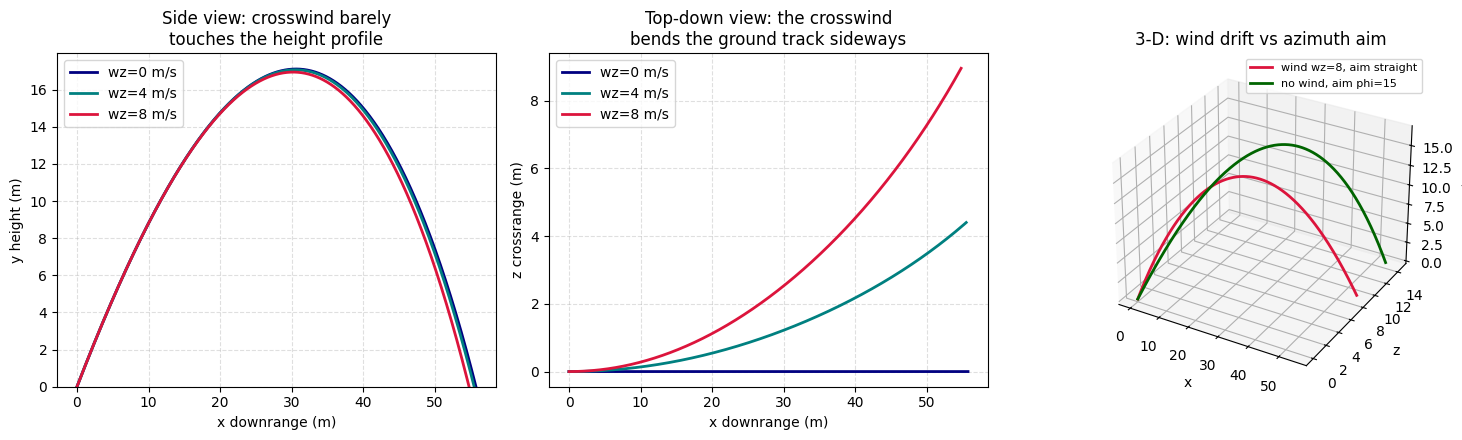

In [5]:
# ── Three views of the crosswind effect ───────────────────────────────────────
fig = plt.figure(figsize=(15,4.5))

# (1) side view: height vs downrange, a few crosswinds
ax1 = fig.add_subplot(1,3,1)
for wz, col in [(0,'navy'), (4,'teal'), (8,'crimson')]:
    _,S = integrate3d(u_fixed, 45, 0, 0.01, (0,0,wz))
    ax1.plot(S[:,0], S[:,1], color=col, lw=2, label=f'wz={wz} m/s')
ax1.set_xlabel('x downrange (m)'); ax1.set_ylabel('y height (m)')
ax1.set_title('Side view: crosswind barely\ntouches the height profile')
ax1.legend(); ax1.grid(True, ls='--', alpha=0.4); ax1.set_ylim(bottom=0)

# (2) top-down: crossrange drift grows with range
ax2 = fig.add_subplot(1,3,2)
for wz, col in [(0,'navy'), (4,'teal'), (8,'crimson')]:
    _,S = integrate3d(u_fixed, 45, 0, 0.01, (0,0,wz))
    ax2.plot(S[:,0], S[:,2], color=col, lw=2, label=f'wz={wz} m/s')
ax2.set_xlabel('x downrange (m)'); ax2.set_ylabel('z crossrange (m)')
ax2.set_title('Top-down view: the crosswind\nbends the ground track sideways')
ax2.legend(); ax2.grid(True, ls='--', alpha=0.4)

# (3) 3-D view: wind drift vs azimuth aim
ax3 = fig.add_subplot(1,3,3, projection='3d')
_,Sa = integrate3d(u_fixed, 45, 0, 0.01, (0,0,8))      # pushed by wind
_,Sb = integrate3d(u_fixed, 45, 15, 0.01, (0,0,0))     # aimed off by azimuth
ax3.plot(Sa[:,0], Sa[:,2], Sa[:,1], color='crimson', lw=2, label='wind wz=8, aim straight')
ax3.plot(Sb[:,0], Sb[:,2], Sb[:,1], color='darkgreen', lw=2, label='no wind, aim phi=15')
ax3.set_xlabel('x'); ax3.set_ylabel('z'); ax3.set_zlabel('y')
ax3.set_title('3-D: wind drift vs azimuth aim'); ax3.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Notice in the top-down view: crossrange drift is small early and grows late in the flight.
# That "grows with time" signature is exactly how an inverse model can later tell wind from aim.

## My forward PINN for the 3-D crosswind problem
**Inputs and outputs.** I keep the *time-domain* idea from Notebook 3 but generalise the family:
$$ (\;\xi,\ \theta,\ \phi,\ k,\ w_x,\ w_z\;)\ \longmapsto\ (\,x,\ y,\ z\,). $$
Here $\xi\in[0,1]$ is a **normalised flight fraction** (like the $\xi$ I used for hard
constraints in Notebooks 1–2): $\xi=0$ is launch, $\xi=1$ is impact. Physical time is
$t=\xi\,T_f$ for that flight's duration $T_f$.

**The new trick: I *infer* the impact time.** In Notebook 3, $T_f$ came from a precomputed RK4
lookup table over $(\theta,k)$. In 3-D-with-wind that table would need five axes and be far too
expensive — the curse of dimensionality. So instead I train a **second, small network**
$$ T_\psi(\theta,\phi,k,w_x,w_z)\ \longmapsto\ T_f>0 $$
jointly with the trajectory network. Nothing tells it the answer directly; it is forced to the
right value by the **landing condition** $y(\xi{=}1)=0$ together with the physics. This is what
my prof means by *"infer impact time"*, and it removes the lookup table entirely (which also
settles the honesty worry I had about the table in Notebook 3).

**Hard constraint — but only at one end this time.** In Notebooks 1–2 I wrote
$y=\xi(1-\xi)N(\xi)$ to *bake in* both $y(0)=0$ **and** $y(1)=0$, because back then I knew
exactly where it landed. Here I *don't* know the landing — that is the very thing I am
inferring — so I only hard-wire the **launch** end:
$$ x=\xi\,N_x\,x_{\text{ref}},\quad y=\xi\,N_y\,y_{\text{ref}},\quad z=\xi\,N_z\,z_{\text{ref}}. $$
Multiplying by $\xi$ forces $x(0)=y(0)=z(0)=0$ automatically, so the launch-position loss term
disappears. The landing end is left *free* on purpose, so the landing loss has something to
push against — that push is what trains $T_\psi$.

**The chain-rule factor I rely on.** Because $t=\xi T_f$, every time derivative gains a factor
$1/T_f$: $\dot{(\cdot)}=\frac1{T_f}\frac{\partial(\cdot)}{\partial\xi}$. Autograd differentiates
w.r.t. the $\xi$ leaf; I divide by $T_f$ to get physical velocities and accelerations. Since
$T_f$ itself is a network output, gradients flow into $T_\psi$ through this factor too — that is
literally how "make the physics work" teaches the network the correct flight time.

In [6]:
# ── Reference scales (so every normalised quantity is ~O(1)) ──────────────────
# We take the "biggest" flight in range (no drag, highest elevation) to set scales.
x_ref  = integrate3d(u_fixed, 45,        0, k_min, (0,0,0))[1][:,0].max()   # largest range
y_ref  = integrate3d(u_fixed, theta_max, 0, k_min, (0,0,0))[1][:,1].max()   # largest height
z_ref  = x_ref                                                              # crossrange <= range
T_scale= integrate3d(u_fixed, theta_max, 0, k_min, (0,0,0))[0][-1]          # longest flight time
theta_ref, phi_ref = 90.0, max(abs(phi_min), phi_max)
k_ref  = max(k_max, 1e-6)
w_ref  = max(abs(w_min), w_max)
print(f"x_ref={x_ref:.2f}m  y_ref={y_ref:.2f}m  z_ref={z_ref:.2f}m  T_scale={T_scale:.3f}s")

# ── Build the per-flight feature vector [theta,phi,k,wx,wz] (normalised) ───────
# This 5-vector is what BOTH networks share (the trajectory net also gets xi in front).
def cfeat(theta, phi, k, wx, wz, n):
    row = torch.tensor([[theta/theta_ref, phi/phi_ref, k/k_ref, wx/w_ref, wz/w_ref]],
                       dtype=torch.float32, device=device)
    return row.repeat(n, 1)                       # shape [n, 5]

x_ref=91.74m  y_ref=34.40m  z_ref=91.74m  T_scale=5.297s


In [7]:
# ── Two networks ──────────────────────────────────────────────────────────────
# Tanh everywhere: a PINN differentiates the network TWICE, and Tanh is smooth and
# infinitely differentiable. ReLU's 2nd derivative is 0 -> the physics loss would be
# meaningless. (This is the single most important architectural rule for PINNs.)

class TrajNet(nn.Module):
    """[xi, theta,phi,k,wx,wz] (6 in) -> [Nx,Ny,Nz] (3 raw outputs, scaled+masked later)."""
    def __init__(self, N_HIDDEN=64, N_LAYERS=5):
        super().__init__()
        act = nn.Tanh
        layers = [nn.Linear(6, N_HIDDEN), act()]
        for _ in range(N_LAYERS-1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), act()]
        layers += [nn.Linear(N_HIDDEN, 3)]                # 3 outputs: x,y,z (no final activation)
        self.net = nn.Sequential(*layers)
    def forward(self, z): return self.net(z)

class TimeNet(nn.Module):
    """[theta,phi,k,wx,wz] (5 in) -> ONE positive number: the inferred impact time T_f."""
    def __init__(self, N_HIDDEN=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(5, N_HIDDEN), nn.Tanh(),
                                 nn.Linear(N_HIDDEN, N_HIDDEN), nn.Tanh(),
                                 nn.Linear(N_HIDDEN, 1))
    def forward(self, c):
        # softplus keeps T_f strictly positive; T_scale sets a sensible starting magnitude,
        # +0.1 stops it collapsing to ~0 early in training.
        return T_scale * torch.nn.functional.softplus(self.net(c)) + 0.1

traj  = TrajNet().to(device)
tnet  = TimeNet().to(device)
print(traj); print(tnet)
print("trainable params:", sum(p.numel() for p in traj.parameters()) +
                            sum(p.numel() for p in tnet.parameters()))

TrajNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=3, bias=True)
  )
)
TimeNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
trainable params: 18564


## The loss — encoding the 3-D ODE system with *no data*, and inferring $T_f$
Just like every PINN so far, this trains on physics, not examples. Three penalties, each already
normalised to be order 1 so the loss weights express *priorities*, not hidden unit conversions:

- **(a) Initial velocity** at $\xi=0$: $\dot x(0)=u\cos\theta\cos\phi$, $\dot y(0)=u\sin\theta$,
  $\dot z(0)=u\cos\theta\sin\phi$, each divided by $u$. (I don't need an initial-*position* term
  — the $\times\xi$ hard constraint already guarantees $\mathbf r(0)=0$.)
- **(b) Landing anchor**: $y(\xi{=}1)=0$, normalised by $y_{\text{ref}}$. This is the term that
  *teaches the impact time*: the only way to be at ground level at $\xi=1$ while also obeying the
  ICs and the physics is for $T_\psi$ to output the correct duration.
- **(c) Physics residual** at many random $\xi\in(0,1)$: the network's own autograd derivatives
  must satisfy the wind-relative drag equations,
  $R_x=\ddot x+k\,v_{\text{rel}}(v_x-w_x)$, $R_y=\ddot y+g+k\,v_{\text{rel}}v_y$,
  $R_z=\ddot z+k\,v_{\text{rel}}(v_z-w_z)$, each divided by $g$.

**Why the residual is the clever bit.** I never integrate the ODE to train the PINN. I sample
times, ask the network for $\mathbf r(\xi)$, differentiate *the network* twice with autograd to
get $\ddot{\mathbf r}$, and penalise how far those violate the equations of motion. The chain
rule's $1/T_f$ factor threads $T_\psi$ through every derivative, so a wrong flight time shows up
as physics violation — that is the pressure that pins $T_f$.

In [8]:
# ── autograd helper: d(output)/d(xi leaf); keep the graph for a 2nd derivative ─
def d_dxi(out, xi):
    return torch.autograd.grad(out, xi, grad_outputs=torch.ones_like(out),
                               create_graph=True)[0]

# ── Collocation sampler: mostly uniform, but DENSER near landing (xi=1) ────────
# Steep-drop flights (low angle, high drag) change fastest just before impact, so
# extra physics points there sharpen exactly the region that was failing before.
def sample_xi(n_uniform=48, n_land=16):
    a = torch.rand(n_uniform, 1)
    b = 1.0 - torch.rand(n_land, 1)**2          # squashed toward 1.0 (the landing end)
    return torch.cat([a, b], 0).to(device).requires_grad_(True)

# ── Losses for ONE flight, given its collocation xi. Both optimisers reuse this. ─
def flight_losses(th, ph, k, wx, wz, xi_col):
    thr, phr = np.radians(th), np.radians(ph)
    vx0 = u_fixed*np.cos(thr)*np.cos(phr)
    vy0 = u_fixed*np.sin(thr)
    vz0 = u_fixed*np.cos(thr)*np.sin(phr)
    c1  = cfeat(th, ph, k, wx, wz, 1)
    Tf  = tnet(c1)                                   # inferred impact time for THIS flight

    # (a) INITIAL VELOCITY at xi=0
    xi0 = torch.zeros(1,1, requires_grad=True, device=device)
    N0  = traj(torch.cat([xi0, c1], dim=1))
    x0 = xi0*N0[:,0:1]*x_ref; y0 = xi0*N0[:,1:2]*y_ref; z0 = xi0*N0[:,2:3]*z_ref
    vx0p = d_dxi(x0, xi0)/Tf; vy0p = d_dxi(y0, xi0)/Tf; vz0p = d_dxi(z0, xi0)/Tf
    L_icv = torch.mean(((vx0p-vx0)/u_fixed)**2
                     + ((vy0p-vy0)/u_fixed)**2
                     + ((vz0p-vz0)/u_fixed)**2)

    # (b) LANDING ANCHOR y(xi=1)=0  -> this is the signal that trains T_f
    xi1 = torch.ones(1,1, device=device)
    y1  = xi1*traj(torch.cat([xi1, c1], dim=1))[:,1:2]*y_ref
    L_bc = torch.mean((y1/y_ref)**2)

    # (c) PHYSICS RESIDUAL at the collocation points
    n   = xi_col.shape[0]
    cM  = cfeat(th, ph, k, wx, wz, n)
    N   = traj(torch.cat([xi_col, cM], dim=1))
    x = xi_col*N[:,0:1]*x_ref; y = xi_col*N[:,1:2]*y_ref; z = xi_col*N[:,2:3]*z_ref
    TfM = Tf.repeat(n,1)
    vx = d_dxi(x,xi_col)/TfM; vy = d_dxi(y,xi_col)/TfM; vz = d_dxi(z,xi_col)/TfM
    ax = d_dxi(vx,xi_col)/TfM; ay = d_dxi(vy,xi_col)/TfM; az = d_dxi(vz,xi_col)/TfM
    vrx, vry, vrz = vx-wx, vy, vz-wz                                  # AIR-relative
    vr = torch.sqrt(vrx*vrx + vry*vry + vrz*vrz + 1e-12)
    Rx = ax + k*vr*vrx; Ry = ay + g + k*vr*vry; Rz = az + k*vr*vrz
    L_ph = torch.mean((Rx/g)**2 + (Ry/g)**2 + (Rz/g)**2)
    return L_icv, L_bc, L_ph

num_pairs_per_epoch = 16     # random flights per Adam step
def compute_losses():        # stochastic batch (used by Adam)
    Li = Lb = Lp = torch.zeros((), device=device)
    for _ in range(num_pairs_per_epoch):
        th = np.random.uniform(theta_min, theta_max)
        ph = np.random.uniform(phi_min,   phi_max)
        k  = np.random.uniform(k_min,     k_max)
        wx = np.random.uniform(w_min,     w_max)
        wz = np.random.uniform(w_min,     w_max)
        li, lb, lp = flight_losses(th, ph, k, wx, wz, sample_xi())
        Li = Li + li; Lb = Lb + lb; Lp = Lp + lp
    n = num_pairs_per_epoch
    return Li/n, Lb/n, Lp/n


## Training strategy and the reasoning behind each knob
I train in **two stages**, which is standard for PINNs and is the single biggest thing that
fixed my earlier failures on the steep, high-drag flights.

**Stage 1 — Adam** (learning rate $2\times10^{-3}$ cosine-annealed to $10^{-5}$). Adam is robust
and explores: it finds the right basin, including a sensible flight time, on fresh random flights
every epoch so the network learns the *map* rather than memorising trajectories.

**Stage 2 — L-BFGS.** Adam gets close but leaves a lot of accuracy on the table. L-BFGS is a
*second-order* optimiser (it uses curvature, not just slope) and polishes the solution to far
lower loss. It has one requirement: the loss must be **deterministic** across its internal
line-search evaluations, so I run it on a **fixed** batch of flights and collocation points rather
than fresh random ones. This stage is why the final trajectories sit almost on top of RK4.

**Loss weights are priorities** (all terms are already O(1)). I now weight the **landing anchor
much higher** ($w_{bc}=40$) than before, because my earlier steep flights failed by landing at the
wrong *time* — and the landing loss is precisely what trains $T_\psi$. Initial velocity stays high
($20$) and the physics residual ($10$) shapes the curve between the ends.

**Denser collocation near landing.** Steep flights change fastest just before impact, so I sample
extra physics points near $\xi=1$ — reinforcing exactly the region that used to go wrong.

Debugging rule of thumb: if the *start* drifts, raise the IC-velocity weight; if it
*over/undershoots the ground*, raise the landing weight (and suspect $T_\psi$); if the *shape*
between the ends is wrong, raise the physics weight.


In [9]:
# ── Loss weights: landing anchored HARD so T_f (and steep flights) come out right ─
w_icv, w_bc, w_ph = 20.0, 40.0, 10.0
params = list(traj.parameters()) + list(tnet.parameters())

# ═══ STAGE 1: Adam on fresh random flights ════════════════════════════════════
num_epochs = 4000                      # a few minutes on CPU; raise for more accuracy
opt   = torch.optim.Adam(params, lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs, eta_min=1e-5)
hist  = {'icv':[], 'bc':[], 'ph':[], 'total':[]}
print(f"STAGE 1 (Adam)\n{'epoch':>6}{'total':>12}{'IC vel':>12}{'landing':>12}{'physics':>12}")
for ep in range(num_epochs):
    opt.zero_grad()
    l_icv, l_bc, l_ph = compute_losses()
    loss = w_icv*l_icv + w_bc*l_bc + w_ph*l_ph
    loss.backward(); opt.step(); sched.step()
    hist['icv'].append(l_icv.item()); hist['bc'].append(l_bc.item())
    hist['ph'].append(l_ph.item());   hist['total'].append(loss.item())
    if ep % 400 == 0 or ep == num_epochs-1:
        print(f"{ep:>6}{loss.item():>12.3e}{l_icv.item():>12.3e}"
              f"{l_bc.item():>12.3e}{l_ph.item():>12.3e}")
print("Adam done.\n")

# ═══ STAGE 2: L-BFGS fine-tuning on a FIXED batch ═════════════════════════════
# L-BFGS re-evaluates the loss several times per step (its line search), so the loss
# MUST NOT change between calls. We therefore freeze a fixed set of flights + xi points.
rng_fix = np.random.default_rng(12345)
N_FIX   = 48
fix_batch = []
for _ in range(N_FIX):
    th = rng_fix.uniform(theta_min, theta_max); ph = rng_fix.uniform(phi_min, phi_max)
    k  = rng_fix.uniform(k_min, k_max)
    wx = rng_fix.uniform(w_min, w_max);         wz = rng_fix.uniform(w_min, w_max)
    xi_np = np.sort(np.concatenate([rng_fix.uniform(0,1,48),
                                    1.0 - rng_fix.uniform(0,1,16)**2]))   # dense near landing
    fix_batch.append((th, ph, k, wx, wz, xi_np))

lbfgs_log = []
def closure():
    opt_lbfgs.zero_grad()
    Li = Lb = Lp = torch.zeros((), device=device)
    for (th, ph, k, wx, wz, xi_np) in fix_batch:
        xi_col = torch.tensor(xi_np.reshape(-1,1), dtype=torch.float32,
                              device=device, requires_grad=True)
        li, lb, lp = flight_losses(th, ph, k, wx, wz, xi_col)
        Li = Li + li; Lb = Lb + lb; Lp = Lp + lp
    n = len(fix_batch)
    loss = w_icv*Li/n + w_bc*Lb/n + w_ph*Lp/n
    loss.backward(); lbfgs_log.append(loss.item())
    return loss

opt_lbfgs = torch.optim.LBFGS(params, lr=1.0, max_iter=300, history_size=50,
                              tolerance_grad=1e-9, tolerance_change=1e-12,
                              line_search_fn='strong_wolfe')
print("STAGE 2 (L-BFGS fine-tuning on fixed batch)...")
opt_lbfgs.step(closure)   # note: .step() returns the INITIAL loss, so we read the log
print(f"L-BFGS done after {len(lbfgs_log)} evals. "
      f"fixed-batch loss {lbfgs_log[0]:.3e} -> {min(lbfgs_log):.3e}  "
      f"({lbfgs_log[0]/min(lbfgs_log):.1f}x lower)")


STAGE 1 (Adam)
 epoch       total      IC vel     landing     physics
     0   3.075e+01   1.028e+00   7.768e-03   9.879e-01
   400   4.877e-01   6.030e-03   5.153e-03   1.610e-02
   800   1.101e-01   2.182e-03   4.324e-04   4.915e-03
  1200   1.111e-01   1.732e-03   2.896e-04   6.485e-03
  1600   5.548e-02   1.195e-03   3.491e-04   1.763e-03
  2000   5.578e-02   1.472e-03   3.506e-05   2.493e-03
  2400   2.710e-02   3.571e-04   8.369e-06   1.963e-03
  2800   1.750e-02   2.721e-04   5.815e-05   9.733e-04
  3200   1.568e-02   1.442e-04   2.999e-05   1.160e-03
  3600   2.090e-02   3.008e-04   4.065e-05   1.326e-03
  3999   1.925e-02   2.630e-04   2.170e-05   1.312e-03
Adam done.

STAGE 2 (L-BFGS fine-tuning on fixed batch)...
L-BFGS done after 320 evals. fixed-batch loss 1.772e-02 -> 3.143e-03  (5.6x lower)


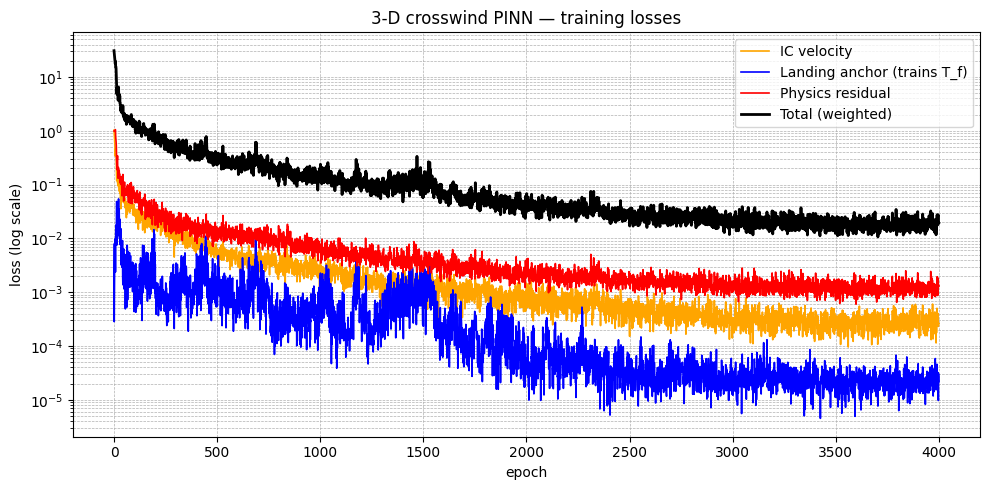

In [10]:
# ── Loss curves (log scale) ───────────────────────────────────────────────────
ep = np.arange(num_epochs)
plt.figure(figsize=(10,5))
plt.plot(ep, hist['icv'],  label='IC velocity', color='orange', lw=1.2)
plt.plot(ep, hist['bc'],   label='Landing anchor (trains T_f)', color='blue', lw=1.2)
plt.plot(ep, hist['ph'],   label='Physics residual', color='red', lw=1.2)
plt.plot(ep, hist['total'],label='Total (weighted)', color='black', lw=2.0)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('loss (log scale)')
plt.title('3-D crosswind PINN — training losses'); plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5); plt.tight_layout(); plt.show()

## Validation — does the surrogate match RK4, and did it infer the right impact time?
The honest test of a forward PINN is to pick flights it never saw, run the trusted RK4 integrator,
and overlay. I report four numbers per flight: the **whole-trajectory RMSE** in each coordinate
(the fair, full-path error, not just the endpoint), the **downrange range** error, the
**crossrange drift** error (the point of this notebook), and the **inferred flight time** $T_f$
against RK4's. I include the previously-hard flight 3 (low angle, high drag, opposing winds) on
purpose — it is the one the two-stage training was meant to fix.


 flight   RMSE_x   RMSE_y   RMSE_z  RMSE_3D  range e  cross e    Tf e
      1     0.52     0.44     0.42     0.79     0.67     0.62   0.099
      2     0.48     0.26     0.10     0.55     0.62     0.15   0.063
      3     0.03     0.07     0.08     0.11     0.05     0.11   0.022

mean whole-trajectory RMSE over the 3 flights: 0.49 m


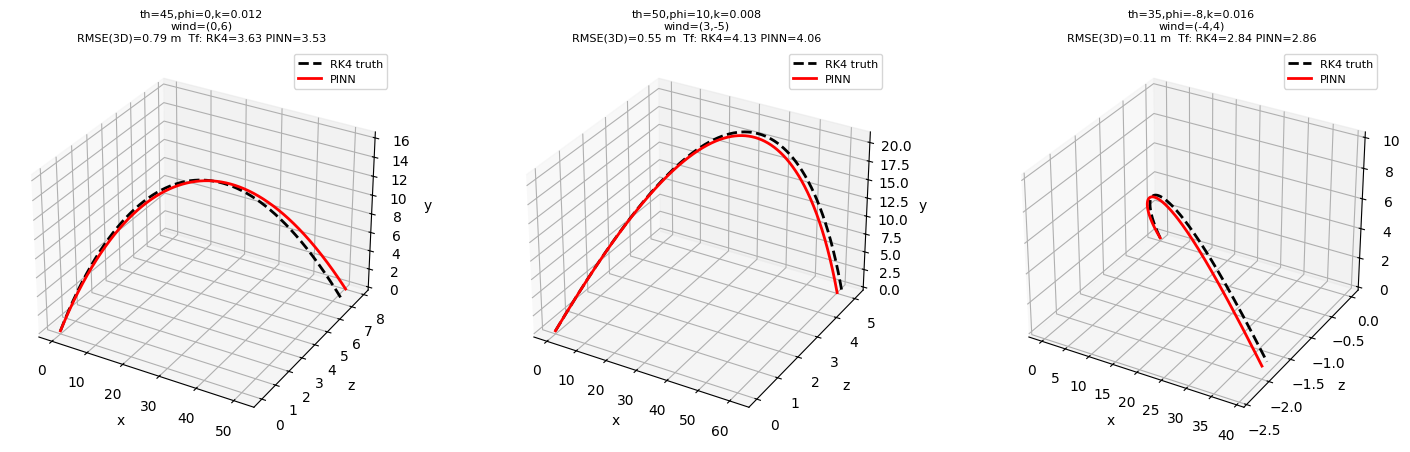

In [11]:
# ── Validate on unseen flights, and report whole-trajectory RMSE ──────────────
traj.eval(); tnet.eval()
test_flights = [
    (45,  0,  0.012,  0,  6),     # pure crosswind
    (50, 10,  0.008,  3, -5),     # aim + wind mixed
    (35, -8,  0.016, -4,  4),     # low, draggy, opposing winds (the hard one)
]
fig = plt.figure(figsize=(15,4.5))
rmse_all = []
print(f"{'flight':>7}{'RMSE_x':>9}{'RMSE_y':>9}{'RMSE_z':>9}{'RMSE_3D':>9}"
      f"{'range e':>9}{'cross e':>9}{'Tf e':>8}")
for i,(th,ph,k,wx,wz) in enumerate(test_flights):
    T,S = integrate3d(u_fixed, th, ph, k, (wx,0,wz))         # RK4 truth
    with torch.no_grad():
        Tf = tnet(cfeat(th,ph,k,wx,wz,1)).item()
        xi = torch.linspace(0,1,len(T), device=device).unsqueeze(1)
        N  = traj(torch.cat([xi, cfeat(th,ph,k,wx,wz,len(T))], dim=1))
        xp = (xi[:,0]*N[:,0]*x_ref).cpu().numpy()
        yp = (xi[:,0]*N[:,1]*y_ref).cpu().numpy()
        zp = (xi[:,0]*N[:,2]*z_ref).cpu().numpy()
    # whole-trajectory RMSE (PINN vs RK4 at equal flight-fraction) -----------------
    rmse_x = np.sqrt(np.mean((xp-S[:,0])**2))
    rmse_y = np.sqrt(np.mean((yp-S[:,1])**2))
    rmse_z = np.sqrt(np.mean((zp-S[:,2])**2))
    rmse_3d= np.sqrt(np.mean((xp-S[:,0])**2+(yp-S[:,1])**2+(zp-S[:,2])**2))
    rng_err  = abs(xp[-1]-S[-1,0]); cross_err = abs(zp[-1]-S[-1,2]); tf_err = abs(Tf-T[-1])
    rmse_all.append(rmse_3d)
    ax = fig.add_subplot(1,3,i+1, projection='3d')
    ax.plot(S[:,0], S[:,2], S[:,1], 'k--', lw=2, label='RK4 truth')
    ax.plot(xp, zp, yp, 'r-', lw=2, label='PINN')
    ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
    ax.set_title(f"th={th},phi={ph},k={k}\nwind=({wx},{wz})\n"
                 f"RMSE(3D)={rmse_3d:.2f} m  Tf: RK4={T[-1]:.2f} PINN={Tf:.2f}", fontsize=8)
    ax.legend(fontsize=8)
    print(f"{i+1:>7}{rmse_x:>9.2f}{rmse_y:>9.2f}{rmse_z:>9.2f}{rmse_3d:>9.2f}"
          f"{rng_err:>9.2f}{cross_err:>9.2f}{tf_err:>8.3f}")
print(f"\nmean whole-trajectory RMSE over the 3 flights: {np.mean(rmse_all):.2f} m")
plt.tight_layout(); plt.show()


## A small sensitivity map: azimuth vs crosswind
A single accuracy number hides the truth, so — as in Notebook 3 — I sweep a plane. Here the two
most interesting axes are **azimuth $\phi$** and **crosswind $w_z$**, because together they
control the crossrange landing. I record the crossrange-impact error (in metres) against RK4
across the plane. I expect low error inside the training box and growth outside it (PINNs
extrapolate poorly, since physics was only enforced inside).

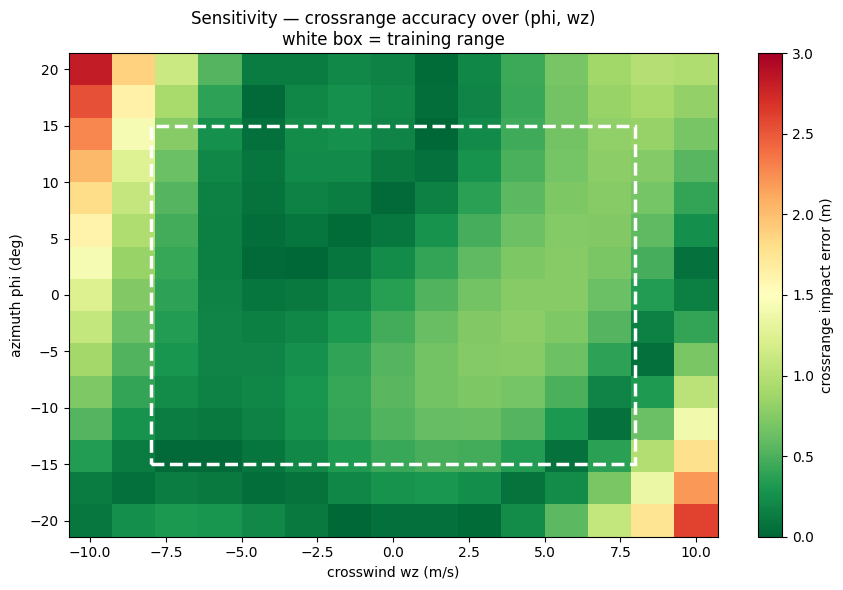

mean crossrange error inside grid: 0.51 m


In [12]:
# ── Sensitivity: crossrange impact error over (phi, wz) ───────────────────────
n_ph, n_wz = 15, 15
phi_sweep = np.linspace(phi_min-5, phi_max+5, n_ph)
wz_sweep  = np.linspace(w_min-2,   w_max+2,   n_wz)
err_grid  = np.full((n_ph, n_wz), np.nan)

traj.eval(); tnet.eval()
with torch.no_grad():
    for a,ph in enumerate(phi_sweep):
        for b,wz in enumerate(wz_sweep):
            T,S = integrate3d(u_fixed, 45, ph, 0.01, (0,0,wz))
            Tf  = tnet(cfeat(45,ph,0.01,0,wz,1)).item()
            xi1 = torch.ones(1,1, device=device)
            z1  = (xi1*traj(torch.cat([xi1, cfeat(45,ph,0.01,0,wz,1)],dim=1))[:,2]*z_ref).item()
            err_grid[a,b] = abs(z1 - S[-1,2])

fig, ax = plt.subplots(figsize=(9,6))
im = ax.pcolormesh(wz_sweep, phi_sweep, err_grid, cmap=plt.cm.RdYlGn_r,
                   vmin=0, vmax=3, shading='auto')
plt.colorbar(im, ax=ax, label='crossrange impact error (m)')
rect = plt.Rectangle((w_min, phi_min), w_max-w_min, phi_max-phi_min,
                     lw=2.5, edgecolor='white', facecolor='none', ls='--')
ax.add_patch(rect)
ax.set_xlabel('crosswind wz (m/s)'); ax.set_ylabel('azimuth phi (deg)')
ax.set_title('Sensitivity — crossrange accuracy over (phi, wz)\nwhite box = training range')
plt.tight_layout(); plt.show()
print(f"mean crossrange error inside grid: {np.nanmean(err_grid):.2f} m")

## What this notebook gives me
I now have a **fast, differentiable, 3-D crosswind surrogate** that generalises over two launch
angles, a drag coefficient, and a two-component wind — and that **infers its own impact time**
with a small companion network, no lookup table required. That surrogate is the fast forward
map I lean on in the inverse and targeting work. Everything here is **deterministic**: one set
of inputs gives exactly one trajectory. Real air is not deterministic, and that is the subject
of the next notebook.